In [ ]:
# Cell 1: Cài đặt thư viện
!pip install -q -U transformers datasets accelerate peft bitsandbytes trl

In [ ]:
import json
import os
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

In [ ]:
# =====================================================================
# Cell 3: ĐỊNH NGHĨA HÀM LOAD DATA THUẦN TEXT 
# =====================================================================
import json
import os
from datasets import Dataset

# Chi kiểm tra và sửa lại chính xác tên 2 file này trong thư mục Kaggle
TRAIN_DATA_PATH = "/kaggle/input/datasets/ohthisischichi/vqa-rag-vietnamculture/final_train.jsonl"
VAL_DATA_PATH   = "/kaggle/input/datasets/ohthisischichi/vqa-rag-vietnamculture/final_val.jsonl" 

def load_text_data(path, limit=None):
    text_list = []
    
    if not os.path.exists(path):
        print(f"🚨 CẢNH BÁO: Không tìm thấy file tại đường dẫn: {path}")
        return Dataset.from_list([])
        
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit and i >= limit: 
                break
                
            item = json.loads(line)
            
            # 1. Lấy Standalone Question
            sq = item.get("standalone_question") or item.get("question", "")
            
            # 2. Lấy Ngữ cảnh văn hóa 
            context = item.get("cultural_context") or item.get("culture_context", "")
            
            # 3. Lấy Nhãn câu trả lời
            answer = item.get("answer_label") or item.get("answer", "")
            
            text_list.append({
                "culture_context": context,
                "standalone_question": sq,
                "answer_label_explainable": answer
            })
            
    return Dataset.from_list(text_list)

print("✅ Đã định nghĩa hàm load_text_data độc lập cho Train/Val")


# =====================================================================
# TIẾN HÀNH LOAD SONG SONG TẬP TRAIN VÀ VALIDATION
# =====================================================================
print("📥 Đang load tập dữ liệu TRAIN...")
train_dataset = load_text_data(TRAIN_DATA_PATH)

print("📥 Đang load tập dữ liệu VALIDATION...")
val_dataset = load_text_data(VAL_DATA_PATH)

print("\n📊 Thống kê phân chia tập dữ liệu từ file gốc:")
print(f"   - Tập TRAIN tổng cộng: {len(train_dataset)} mẫu")
print(f"   - Tập VALIDATION tổng cộng: {len(val_dataset)} mẫu")

# Xem thử cấu trúc dòng đầu tiên của tập Train để kiểm tra các cột
if len(train_dataset) > 0:
    print("\n👀 Mẫu dòng đầu tiên của tập TRAIN:")
    print(train_dataset[0])

In [ ]:
# Cell 4: Load Qwen2.5-3B + LoRA (Text-only)
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

try:
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_TOKEN")
    login(token=hf_token)
    print("✅ Đăng nhập HuggingFace thành công!")
except Exception as e:
    hf_token = None
    print("⚠️ Chưa cài HF Token")

MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

# ✅ Quantization 4-bit — tiết kiệm VRAM
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

In [ ]:
checkpoint_dir = "/kaggle/working/qwen2.5-vn-culture-adapter"

def formatting_prompts_func(example):
    user_content = f"""Dựa vào ngữ cảnh văn hóa được cung cấp, hãy trả lời câu hỏi sau.
[Ngữ cảnh]: {example['culture_context']}
[Câu hỏi]: {example['standalone_question']}"""
    messages = [
        {"role": "user",      "content": user_content},
        {"role": "assistant", "content": example['answer_label_explainable']}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text}

processed_train = train_dataset.map(
    formatting_prompts_func,
    remove_columns=train_dataset.column_names,
    num_proc=1,
    load_from_cache_file=False
)
print(f"✅ Train: {len(processed_train)}")

def qwen_text_collate_fn(examples):
    texts = [ex["text"] for ex in examples]
    batch = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )
    labels = batch["input_ids"].clone()
    labels[labels == tokenizer.pad_token_id] = -100
    batch["labels"] = labels
    return batch

training_args = TrainingArguments(
    output_dir=checkpoint_dir,
    push_to_hub=True,
    hub_model_id="ohthisischichi/viet-cultural-qa-qwen2.5-lora",
    hub_strategy="checkpoint",
    hub_token=hf_token,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2, 
    max_grad_norm=0.1,              
    gradient_checkpointing=True,
    learning_rate=2e-4,
    num_train_epochs=2,
    logging_steps=10,
    eval_strategy="no",             # Đổi thành "steps" nếu có tập eval, hoặc "no" để tắt hoàn toàn
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    bf16=False, fp16=True,
    optim="paged_adamw_32bit",
    report_to="none",
    remove_unused_columns=False,
    dataloader_num_workers=4,
    dataloader_pin_memory=True
)

from transformers import Trainer
trainer = Trainer(
    model=model,
    train_dataset=processed_train,  # ✅ Không có eval_dataset, trong epoch 1 thì có
    args=training_args,
    data_collator=qwen_text_collate_fn
)

model.config.use_cache = False

from huggingface_hub import snapshot_download
import os

resume_from = snapshot_download(
    repo_id="ohthisischichi/viet-cultural-qa-qwen2.5-lora",
    allow_patterns="last-checkpoint/*"
)
resume_from = os.path.join(resume_from, "last-checkpoint")

# ✅ Sửa nội dung nếu thay đổi eval steps hoặc eval_strategy
trainer_state_path = os.path.join(resume_from, "trainer_state.json")
if os.path.exists(trainer_state_path):
    with open(trainer_state_path, "r") as f:
        state = json.load(f)
    
    state["eval_steps"] = 1000          # Nếu đổi evel_strategy thành "steps" thì sửa lại số này cho khớp, nếu để "no" thì có thể giữ nguyên hoặc xóa đi cũng được
    state["logging_steps"] = 10
    
    with open(trainer_state_path, "w") as f:
        json.dump(state, f, indent=2)
    print("✅ Đã cập nhật trainer_state.json")

print(f"🔄 Resume từ: {resume_from}")
trainer.train(resume_from_checkpoint=resume_from)

trainer.save_model("./qwen2.5-vn-culture-final")
tokenizer.save_pretrained("./qwen2.5-vn-culture-final")
print("🎉 HOÀN THÀNH!")

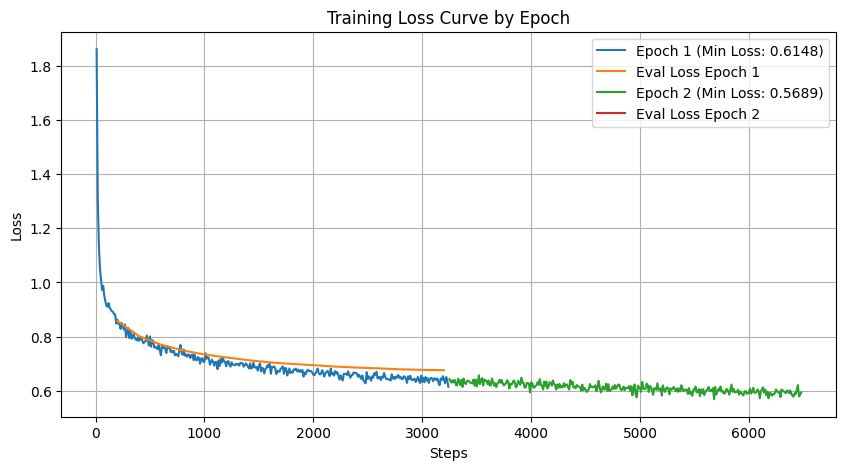

In [15]:
# Ve bieu do loss tu trainer_state.json (log_history).
import json
import os
import math
import matplotlib.pyplot as plt
import pandas as pd

log_path = "../data/evaluation/trainer_state.json"  # Cap nhat duong dan neu can
if not os.path.exists(log_path):
    raise FileNotFoundError(f"Khong tim thay log: {log_path}")

with open(log_path, "r", encoding="utf-8") as f:
    log_data = json.load(f)

log_history = log_data.get("log_history", [])
if not log_history:
    raise ValueError("log_history trong trainer_state.json bi trong.")

df = pd.DataFrame(log_history)

# Lay cac diem train loss (co 'loss')
train_df = df[df["loss"].notna()][["step", "loss", "epoch"]].copy()
train_df = train_df.sort_values("step")

# Lay cac diem eval loss (co 'eval_loss') neu co
eval_df = df[df["eval_loss"].notna()][["step", "eval_loss", "epoch"]].copy()
eval_df = eval_df.sort_values("step")

# Epoch co the la so le, lam tron xuong de nhom dung 2 epoch
train_df["epoch_idx"] = train_df["epoch"].apply(lambda x: int(math.floor(x)))
eval_df["epoch_idx"] = eval_df["epoch"].apply(lambda x: int(math.floor(x)))

# Gioi han theo so epoch trong log (hoac 2 neu muon co dinh)
max_epoch_count = int(math.floor(log_data.get("epoch", 0) or 0))
if max_epoch_count <= 0:
    max_epoch_count = 2
train_df = train_df[train_df["epoch_idx"] < max_epoch_count]
eval_df = eval_df[eval_df["epoch_idx"] < max_epoch_count]

# Truc quan hoa loss theo epoch (epoch bat dau tu 1)
plt.figure(figsize=(10, 5))
for epoch_idx in sorted(train_df["epoch_idx"].unique()):
    epoch_data = train_df[train_df["epoch_idx"] == epoch_idx]
    min_loss = epoch_data["loss"].min()
    plt.plot(
        epoch_data["step"],
        epoch_data["loss"],
        label=f"Epoch {epoch_idx + 1} (Min Loss: {min_loss:.4f})",
    )
    if not eval_df.empty:
        eval_epoch = eval_df[eval_df["epoch_idx"] == epoch_idx]
        if not eval_epoch.empty:
            plt.plot(
                eval_epoch["step"],
                eval_epoch["eval_loss"],
                label=f"Eval Loss Epoch {epoch_idx + 1}",
            )
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve by Epoch")
plt.legend()
plt.grid()
plt.show()